In [6]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the match",
    "The bowler took a five wicket haul",
    "The team won the match in the final over",
    "Fielders saved crucial runs near the boundary",

    # Cooking (3)
    "The chef prepared a delicious pasta dish",
    "Baking requires precise measurements of ingredients",
    "The recipe includes fresh vegetables and spices",

    # Cybersecurity (3)
    "Strong passwords help protect against cyber attacks",
    "Encryption ensures data privacy and security",
    "Firewalls prevent unauthorized access to systems"
]

In [9]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


In [10]:
similarity_matrix = cosine_similarity(embeddings)
similarity_matrix

array([[ 0.9999999 ,  0.5370785 ,  0.42840475,  0.3376491 , -0.00761768,
         0.12796183,  0.04408037,  0.04548454,  0.0213818 , -0.02419311],
       [ 0.5370785 ,  1.0000001 ,  0.2987027 ,  0.29252815,  0.14733213,
         0.06016865,  0.09256157,  0.00677894,  0.02186339, -0.08905271],
       [ 0.42840475,  0.2987027 ,  0.99999994,  0.15187678,  0.00165505,
         0.02312005,  0.03380389, -0.00124968,  0.08077332,  0.11819485],
       [ 0.3376491 ,  0.29252815,  0.15187678,  1.0000001 , -0.001224  ,
         0.04737612,  0.03129018,  0.09785166,  0.06605985,  0.01267797],
       [-0.00761768,  0.14733213,  0.00165505, -0.001224  ,  1.        ,
         0.25972503,  0.44530421,  0.00750652,  0.0450437 ,  0.07745294],
       [ 0.12796183,  0.06016865,  0.02312005,  0.04737612,  0.25972503,
         1.0000001 ,  0.28516525, -0.02899628,  0.05814718, -0.00599829],
       [ 0.04408037,  0.09256157,  0.03380389,  0.03129018,  0.44530421,
         0.28516525,  1.        , -0.00802759

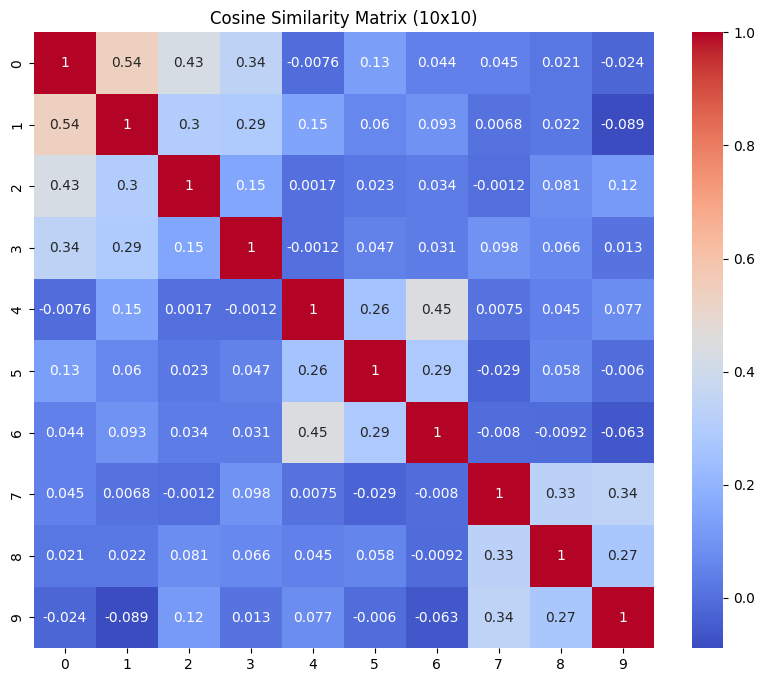

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix (10x10)")
plt.show()

In [12]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = np.argsort(similarities)[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The bowler took a five wicket haul
Similarity Score: 0.7566

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

